In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("faisal012/hyderabad-house-price")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\VENKATESH\.cache\kagglehub\datasets\faisal012\hyderabad-house-price\versions\1


In [2]:
print(path)

C:\Users\VENKATESH\.cache\kagglehub\datasets\faisal012\hyderabad-house-price\versions\1


In [3]:
import os  
file_name = os.listdir(path)[0]

In [4]:
print(file_name)

Hyderbad_House_price.csv


In [5]:
import pandas as pd

df = pd.read_csv(os.path.join(path, file_name))

In [6]:
df.head()

,Unnamed: 0,title,location,price(L),rate_persqft,area_insqft,building_status
0,0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


In [7]:
df['building_status'].value_counts()

building_status
New                   1378
Under Construction    1161
Ready to move          882
Resale                 239
Name: count, dtype: int64

In [8]:
df['Unnamed: 0']

0          0
1          1
2          2
3          3
4          4
        ... 
3655    3655
3656    3656
3657    3657
3658    3658
3659    3659
Name: Unnamed: 0, Length: 3660, dtype: int64

In [9]:
df.drop('Unnamed: 0', axis = 1, inplace = True)

In [10]:
df.head()

,title,location,price(L),rate_persqft,area_insqft,building_status
0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,2 BHK Apartment,Pocharam,60.48,4999,1210,Under Construction
4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


In [11]:
df['location'].value_counts()

location
Mirkhanpet            165
Ameenpur              164
Meerkhanpet           140
Kondapur              107
Shadnagar             102
                     ... 
Sita Meadows            1
Mallepally              1
Jawahar nagar           1
Begum Bazar Chatri      1
Rajeev Nagar            1
Name: count, Length: 359, dtype: int64

In [12]:
df[df['location'] == 'Kompally']

,title,location,price(L),rate_persqft,area_insqft,building_status
11,2 BHK Apartment,Kompally,66.82,4500,1485,Ready to move
37,3 BHK Apartment,Kompally,75.69,4500,1682,Ready to move
135,3 BHK Apartment,Kompally,80.00,5555,1440,Ready to move
557,2 BHK Apartment,Kompally,55.02,4200,1310,Under Construction
558,3 BHK Apartment,Kompally,73.29,4200,1745,Under Construction
559,3 BHK Apartment,Kompally,67.62,4200,1610,Under Construction
699,3 BHK Villa,Kompally,530.00,12217,4338,Under Construction
720,2 BHK Apartment,Kompally,52.50,4200,1250,Ready to move
721,2 BHK Apartment,Kompally,48.55,4200,1156,Ready to move
722,2 BHK Apartment,Kompally,51.66,4200,1230,Ready to move


In [13]:
avg_price_title = df.groupby('title', as_index = False)['price(L)'].mean()

avg_price_title.sort_values('price(L)', ascending = False)

,title,price(L)
16,5 BHK Apartment,2222.833333
20,6 BHK Villa,1042.500000
21,7 BHK Independent House,890.000000
18,5 BHK Villa,602.863636
3,10 BHK Independent House,590.000000
13,4 BHK Independent Floor,485.000000
19,6 BHK Independent House,480.000000
15,4 BHK Villa,474.787234
12,4 BHK Apartment,431.977719
22,8 BHK Independent House,368.666667


In [14]:
# No null values whatsoever 

df.isna().sum()

title              0
location           0
price(L)           0
rate_persqft       0
area_insqft        0
building_status    0
dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            3660 non-null   object 
 1   location         3660 non-null   object 
 2   price(L)         3660 non-null   float64
 3   rate_persqft     3660 non-null   int64  
 4   area_insqft      3660 non-null   int64  
 5   building_status  3660 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 171.7+ KB


In [16]:
import matplotlib.pyplot as plt

(array([3.488e+03, 1.110e+02, 3.400e+01, 1.000e+01, 7.000e+00, 2.000e+00,
        6.000e+00, 1.000e+00, 0.000e+00, 1.000e+00]),
 array([1.320000e+00, 3.611880e+02, 7.210560e+02, 1.080924e+03,
        1.440792e+03, 1.800660e+03, 2.160528e+03, 2.520396e+03,
        2.880264e+03, 3.240132e+03, 3.600000e+03]),
 <BarContainer object of 10 artists>)

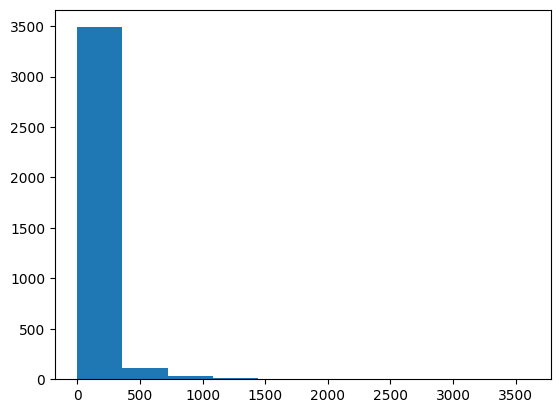

In [17]:
plt.hist(df['price(L)'])

(array([   3.,   17.,  230.,  832.,  917., 1040.,  435.,  130.,   41.,
          15.]),
 array([0.27763174, 1.06873748, 1.85984321, 2.65094895, 3.44205469,
        4.23316043, 5.02426617, 5.81537191, 6.60647765, 7.39758339,
        8.18868912]),
 <BarContainer object of 10 artists>)

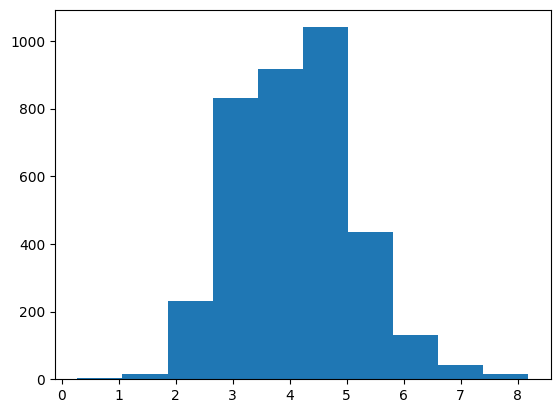

In [18]:
import numpy as np

plt.hist(np.log(df['price(L)']))

# As seen above we have to apply log transformation to the price column as the data is heavily skewed

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            3660 non-null   object 
 1   location         3660 non-null   object 
 2   price(L)         3660 non-null   float64
 3   rate_persqft     3660 non-null   int64  
 4   area_insqft      3660 non-null   int64  
 5   building_status  3660 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 171.7+ KB


In [20]:
df.describe()

,price(L),rate_persqft,area_insqft
count,3660.000000,3660.000000,3660.000000
mean,109.624350,5165.003005,2023.506284
std,197.596948,5316.490320,1829.832163
min,1.320000,125.000000,118.000000
25%,26.137500,1555.000000,1280.000000
50%,61.130000,4703.000000,1620.000000
75%,116.000000,6800.000000,2080.000000
max,3600.000000,112474.000000,45000.000000


In [21]:
df.groupby('building_status')['price(L)'].mean()

building_status
New                    36.067743
Ready to move         168.870238
Resale                 78.866360
Under Construction    158.252506
Name: price(L), dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1fa2d1e18a0>,
 'caps': [<matplotlib.lines.Line2D at 0x1fa2d1e1ea0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1fa2d1e16c0>],
 'medians': [<matplotlib.lines.Line2D at 0x1fa2d1e24a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1fa2d1e27a0>],
 'means': []}

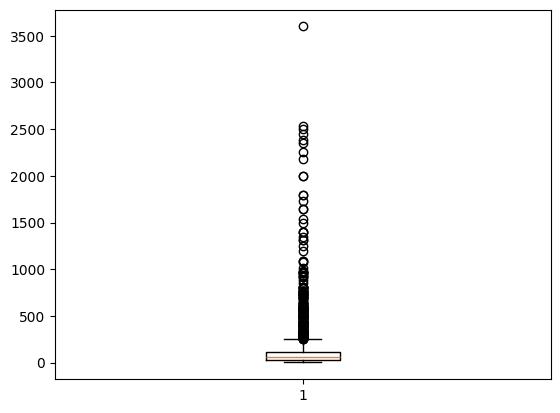

In [22]:
plt.boxplot(df['price(L)'])

In [23]:
df['price(L)'].max()

np.float64(3600.0)

In [24]:
df[df['price(L)'] == df['price(L)'].max()]

,title,location,price(L),rate_persqft,area_insqft,building_status
2886,6 BHK Villa,Jubilee Hills,3600.0,42352,8500,Ready to move


In [25]:
df['location'].value_counts()

location
Mirkhanpet            165
Ameenpur              164
Meerkhanpet           140
Kondapur              107
Shadnagar             102
                     ... 
Sita Meadows            1
Mallepally              1
Jawahar nagar           1
Begum Bazar Chatri      1
Rajeev Nagar            1
Name: count, Length: 359, dtype: int64

In [26]:
location_counts = df['location'].value_counts()

rare_locations = location_counts[location_counts <= 10].index

print(len(rare_locations))

279


In [27]:
df['location'] = df['location'].apply(lambda x: 'Other' if x in rare_locations else x)

In [28]:
df['location'].value_counts()

location
Other          743
Mirkhanpet     165
Ameenpur       164
Meerkhanpet    140
Kondapur       107
              ... 
Dammaiguda      11
Moosapet        11
Hitech City     11
LB Nagar        11
Gandipet        11
Name: count, Length: 81, dtype: int64

In [29]:
df.head()

,title,location,price(L),rate_persqft,area_insqft,building_status
0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction
1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction
2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction
3,2 BHK Apartment,Other,60.48,4999,1210,Under Construction
4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction


In [30]:
df['area_insqft'].min()

np.int64(118)

In [31]:
title_count = df['title'].value_counts()



In [32]:
df['title'].str.extract(r"^(\d+)").isna().sum()

0    1617
dtype: int64

In [33]:
df['bhk'] = df['title'].str.extract(r"^(\d+)").astype(float)

In [34]:
df.head()

,title,location,price(L),rate_persqft,area_insqft,building_status,bhk
0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction,3.0
1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction,3.0
2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction,2.0
3,2 BHK Apartment,Other,60.48,4999,1210,Under Construction,2.0
4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction,3.0


In [35]:
df.isna().sum()

title                 0
location              0
price(L)              0
rate_persqft          0
area_insqft           0
building_status       0
bhk                1617
dtype: int64

In [36]:
df['bhk'] = df['bhk'].fillna(0)

In [37]:
df.isna().sum()

title              0
location           0
price(L)           0
rate_persqft       0
area_insqft        0
building_status    0
bhk                0
dtype: int64

In [38]:
df["property_type"] = df["title"].str.replace(
    r"^\d+\s*(BHK|RK)?\s*", 
    "", 
    regex=True
)
df.head()

,title,location,price(L),rate_persqft,area_insqft,building_status,bhk,property_type
0,3 BHK Apartment,Nizampet,108.00,6000,1805,Under Construction,3.0,Apartment
1,3 BHK Apartment,Bachupally,85.80,5500,1560,Under Construction,3.0,Apartment
2,2 BHK Apartment,Dundigal,55.64,5200,1070,Under Construction,2.0,Apartment
3,2 BHK Apartment,Other,60.48,4999,1210,Under Construction,2.0,Apartment
4,3 BHK Apartment,Kollur,113.00,5999,1900,Under Construction,3.0,Apartment


In [39]:
df.isna().sum()

title              0
location           0
price(L)           0
rate_persqft       0
area_insqft        0
building_status    0
bhk                0
property_type      0
dtype: int64

In [40]:
df['property_type'].value_counts()

property_type
Residential Plot     1617
Apartment            1600
Villa                 208
Independent House     202
Independent Floor      30
Studio Apartment        3
Name: count, dtype: int64

In [41]:
df = df.drop(columns = ['title'])
df.head()

,location,price(L),rate_persqft,area_insqft,building_status,bhk,property_type
0,Nizampet,108.00,6000,1805,Under Construction,3.0,Apartment
1,Bachupally,85.80,5500,1560,Under Construction,3.0,Apartment
2,Dundigal,55.64,5200,1070,Under Construction,2.0,Apartment
3,Other,60.48,4999,1210,Under Construction,2.0,Apartment
4,Kollur,113.00,5999,1900,Under Construction,3.0,Apartment


In [42]:
df.to_csv('cleaed_data.csv')

In [43]:
X = df.drop(columns = ['price(L)', 'rate_persqft'])
y = df['price(L)']

y = np.log(y)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 44)

In [46]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(2928, 5)
(732, 5)
(2928,)
(732,)


In [47]:
ohe = OneHotEncoder()
ss = StandardScaler()

lr = LinearRegression()
lasso = Lasso()
ridge = Ridge()

In [48]:
X.head()

,location,area_insqft,building_status,bhk,property_type
0,Nizampet,1805,Under Construction,3.0,Apartment
1,Bachupally,1560,Under Construction,3.0,Apartment
2,Dundigal,1070,Under Construction,2.0,Apartment
3,Other,1210,Under Construction,2.0,Apartment
4,Kollur,1900,Under Construction,3.0,Apartment


In [49]:
col_tr = make_column_transformer((OneHotEncoder(sparse_output = False, handle_unknown = 'ignore'),
                                ['location', 'building_status', 'property_type']), 
                                remainder = 'passthrough')

In [50]:
pipe = make_pipeline(col_tr, ss, lr)

pipe.fit(X_train, y_train)

y_pred_lr = pipe.predict(X_test)

print(r2_score(y_test, y_pred_lr))




0.7740496889884807


In [51]:
for a in [0.0001, 0.001, 0.01, 0.1, 1, 10]:
    model = Lasso(alpha=a, max_iter=10000)
    pipe = make_pipeline(col_tr, ss, model)
    pipe.fit(X_train, y_train)

    y_pred_lasso = pipe.predict(X_test)

    print(r2_score(y_test, y_pred_lasso))

0.7740380825770244
0.7738799548578532
0.7674882443605329
0.6790198748930829
-0.0015438538799932289
-0.0015438538799932289


In [52]:
pipe = make_pipeline(col_tr, ss, ridge)

pipe.fit(X_train, y_train)

y_pred_ridge = pipe.predict(X_test)

print(r2_score(y_test, y_pred_ridge))

0.7740434425822409


In [53]:
import pickle

In [54]:
pickle.dump(pipe, open('model.pkl', 'wb'))

In [56]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
pipe = make_pipeline(col_tr, ss, model)

pipe.fit(X_train, y_train)

y_pred_rf = pipe.predict(X_test)

print(r2_score(y_test, y_pred_rf))


0.8320155059056222


In [62]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error

In [63]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
}


In [64]:
results = []

for name, model in models.items():
    pipe = make_pipeline(col_tr, StandardScaler(), model)

    final_model = TransformedTargetRegressor(
        regressor=pipe,
        func=np.log,
        inverse_func=np.exp
    )

    final_model.fit(X_train, y_train)
    y_pred = final_model.predict(X_test)

    results.append({
        "Model": name,
        "R2 Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False)
results_df


,Model,R2 Score,MAE,RMSE
8,XGBoost,0.847334,0.251823,0.403197
5,Gradient Boosting,0.836559,0.270799,0.417183
3,Random Forest,0.834307,0.251104,0.420048
4,Extra Trees,0.832080,0.241105,0.422860
7,SVR,0.765482,0.336845,0.499728
0,Linear Regression,0.756167,0.338976,0.509557
1,Ridge,0.756162,0.338992,0.509562
2,Lasso,0.755615,0.340997,0.510133
6,KNN,0.751187,0.305444,0.514734


In [65]:
best_model = results_df.iloc[0]

print(best_model)

Model        XGBoost
R2 Score    0.847334
MAE         0.251823
RMSE        0.403197
Name: 8, dtype: object


In [66]:
import pickle

best_model = TransformedTargetRegressor(
    regressor=make_pipeline(
        col_tr,
        StandardScaler(),
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        )
    ),
    func=np.log,
    inverse_func=np.exp
)

best_model.fit(X, y)

pickle.dump(best_model, open("model.pkl", "wb"))
